# ILUSTR 5 — Maszyna numeryczna: błąd reprezentacji, epsilon i klasy złożoności

Pokrywa: slajdy 33–50 („Błąd reprezentacji danych"), 93–99 („Złożoność obliczeniowa")
prezentacji ZW_1 oraz odpowiadające sekcje konspektu („Błąd reprezentacji liczb",
„Złożoność obliczeniowa, klasy złożoności obliczeniowej").

Maszyna numeryczna to każde urządzenie, które ma skończony zestaw instrukcji i zapis liczb
o skończonej precyzji. Konsekwencja: **nie wszystkie liczby da się zapisać** — między
reprezentowalnymi liczbami są dziury. Każda liczba zapisana w pamięci może być obarczona
błędem reprezentacji, którego nie usuwa żadna poprawka algorytmu. Najpierw sprawdzimy
jak duży ten błąd musi być, potem zobaczymy jego strukturę (gdzie dokładnie są dziury),
a na końcu drugą połowę kosztu: złożoność obliczeniową metod, które na takiej maszynie
będą działać.

In [2]:
# Demo 1: eps maszynowy — najmniejszy kwant dodawany do 1.
import numpy as np
import matplotlib.pyplot as plt

eps32 = float(np.nextafter(np.float32(1), np.float32(2)) - np.float32(1))
eps64 = float(np.nextafter(1.0, 2.0) - 1.0)

print(f"float32 (24 bity mantysy):  eps = {eps32:.6e}   ~ 1.19e-7  (konspekt: 1.19e-7)")
print(f"float64 (53 bity mantysy):  eps = {eps64:.6e}   ~ 2.22e-16 (konspekt: 2.22e-16)")
print()
print("Wzór z konspektu: eps = p^(1-n)  =>  float32: 2^(1-24) =", 2**(1-24))
print("                                                float64: 2^(1-53) =", 2**(1-53))

# najmniejszy kwant dodawany do 1 daje liczbe "wyzej" — ale dla innych wykladnikow
# kwant jest INNY (rośnie z rzędem wielkości liczby):
for u in [np.float32(1), np.float32(8), np.float32(1024)]:
    print(f"spacing wokol {u:6}: {np.spacing(u):.3e}   (kolejna liczba odlegla o tyle)")

# Konsekwencja: liczby NIE sa rozmieszczone rownomiernie — patrz Demo 2.

float32 (24 bity mantysy):  eps = 1.192093e-07   ~ 1.19e-7  (konspekt: 1.19e-7)
float64 (53 bity mantysy):  eps = 2.220446e-16   ~ 2.22e-16 (konspekt: 2.22e-16)

Wzór z konspektu: eps = p^(1-n)  =>  float32: 2^(1-24) = 1.1920928955078125e-07
                                                float64: 2^(1-53) = 2.220446049250313e-16
spacing wokol    1.0: 1.192e-07   (kolejna liczba odlegla o tyle)
spacing wokol    8.0: 9.537e-07   (kolejna liczba odlegla o tyle)
spacing wokol 1024.0: 1.221e-04   (kolejna liczba odlegla o tyle)


## Struktura liczb zmiennopozycyjnych: gęstość spada z wielkością

Zapis $x = m \cdot p^c$ z mantysą $m \in [1, p)$ i $n$ cyframi mantysy. W każdej
„oktawie" (między $p^c$ a $p^{c+1}$) jest dokładnie $p^n / (p-1)$... a w systemie
dwójkowym $2^n$ liczb — tyle samo w każdej oktawie, ale oktawy rozciągają się
geometrycznie. Dlatego w pobliżu zera liczby są gęste, a dla wielkich $|x|$ — rzadkie.
I jeszcze jedno: **pomiędzy 0 a najmniejszą liczbą normalną nic nie ma** — dziura podziemna
(subnormalne nie licząc, w float32 zaczyna się od ~1e-38).

Zobaczmy to na obrazku:

Liczb float32 w każdej oktawie: 2^23 = 8388608
Odstęp między liczbami w oktawie [1,2):   2^-23 = 1.1920928955078125e-07
Odstęp w oktawie [1024,2048):             2^-13 = 0.0001220703125
Dziura między 0 a liczbą najmniejszą: 1.18e-38 (subnormalne poniżej).
1e8 + 1 (float32): 100000000.0   <- jedynka ZNIKNELA (spacing 1e8 = 8)


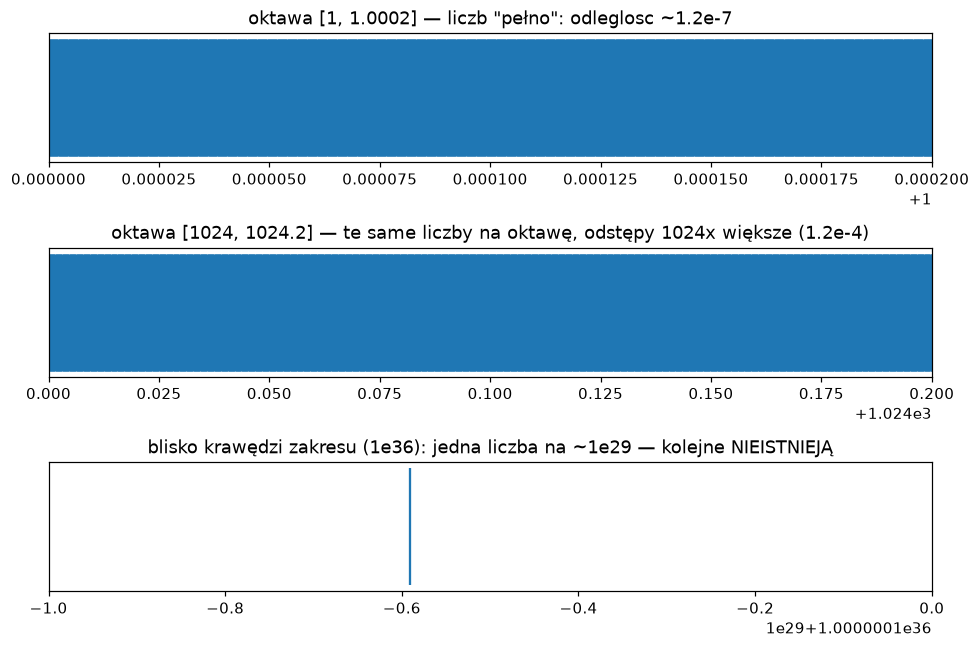

In [4]:
# Demo 2: rozmieszczenie liczb float32 — "tyczki" na osi liczbowej.
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(9, 6))

# oktawa [1, 2): tycki od 1.0 wzwyzej (wycinek szerokosci 2e-4)
lo, hi = np.float32(1.0), np.float32(2.0)
vals = []
u = lo
for k in range(2**21):          # idziemy od 1.0 w gore
    vals.append(u)
    u = np.nextafter(u, np.float32(2))
    if u >= np.float32(1.0002): break
vals = np.array(vals[:2000])
axes[0].vlines(vals, 0, 1, color='tab:blue', lw=.8)
axes[0].set_xlim(1.0, 1.0002); axes[0].set_yticks([])
axes[0].set_title('oktawa [1, 1.0002] — liczb "pełno": odleglosc ~1.2e-7')

# oktawa [1024, 2048): te same 2^24 tycek, ale rozciagniete 1024x szerzej
u = np.float32(1024.)
vals2 = []
for k in range(2000):
    vals2.append(u)
    u = np.nextafter(u, np.float32(2048))
vals2 = np.array(vals2)
axes[1].vlines(vals2, 0, 1, color='tab:blue', lw=.8)
axes[1].set_xlim(1024, 1024.2); axes[1].set_yticks([])
axes[1].set_title('oktawa [1024, 1024.2] — te same liczby na oktawę, odstępy 1024x większe (1.2e-4)')

# oktawa [1e36, 2e36): tyczki znikaja — jedna na ~1e29
u = np.float32(1e36)
vals3 = []
for k in range(2000):
    vals3.append(u)
    u = np.nextafter(u, np.float32(2e36))
    if u >= np.float32(1e29 + 1e36): break
vals3 = np.array(vals3[:40])
axes[2].vlines(vals3, 0, 1, color='tab:blue', lw=1.5)
axes[2].set_xlim(1e36, 1e36 + 1e29); axes[2].set_yticks([])
axes[2].set_title('blisko krawędzi zakresu (1e36): jedna liczba na ~1e29 — kolejne NIEISTNIEJĄ')

plt.tight_layout(); plt.show()

# Ile liczb float32 jest w oktawie [1,2)? Dokladnie 2^23 (bo 24. bit jest "w domyśle").
print("Liczb float32 w każdej oktawie: 2^23 =", 2**23)
print("Odstęp między liczbami w oktawie [1,2):   2^-23 =", 2**-23)
print("Odstęp w oktawie [1024,2048):             2^-13 =", 2**-13)
print("Dziura między 0 a liczbą najmniejszą: 1.18e-38 (subnormalne poniżej).")

# Wniosek: maszyna liczac na float32 "widzi" liczby jak przez sito — w pobliżu zera gesto,
# daleko rzadko. DODAWANIE malej liczby do duzej moze byc niezauważalne:
duza = np.float32(1e8); mala = np.float32(1.0)
print(f"1e8 + 1 (float32): {duza + mala}   <- jedynka ZNIKNELA (spacing 1e8 = {np.spacing(duza):.0f})")

## Zagadka z wykładu: 9 cyfr stałopozycyjnie vs 3 cyfry zmiennopozycyjnie

Slajdy 35–38 zadają zagadkę: zapisać dowolną liczbę z [10, 999 999 999] z błędem < 5%.
Zapis stałopozycyjny (np. 9 cyfr na wszystkie pozycje) daje błąd znikomy dla dużych liczb,
ale katastrofalny... nie, odwrotnie — sprawdźmy! Otóż w zapisie **stałopozycyjnym**
błąd rośnie dla liczb MAŁYCH (bo kwant jest stały, a wartość mała), w **zmiennopozycyjnym**
błąd jest proporcjonalny do samej liczby (mantysa decyduje), więc w jednostkach
relatywnych stały. Wykres poniżej rozstrzyga zagadkę:

        liczba | stałopoz. (9 cyfr) |     błąd |  zmiennopoz. (3 cyfry) |     błąd
          10.5 |                 10 |   4.762% |                   11.0 |   4.762%
         10.49 |                 10 |   4.671% |                   10.0 |   4.671%
          11.5 |                 12 |   4.348% |                   11.0 |   4.348%
   66666.66666 |              66667 |   0.001% |                67000.0 |   0.500%
     1024772.7 |            1024773 |   0.000% |              1000000.0 |   2.417%
   720342529.5 |          720342530 |   0.000% |            720000000.0 |   0.048%

Wzór na błąd w zapisie zmiennopozycyjnym: eps = p^(1-n); tu p=10, n=2 -> 5%
(mantysa 2 cyfry znaczące: kwant na ostatniej cyfrze mantysy to 10% mantysy,
 czyli najgorszy przypadek przy zaokrąglaniu do najbliższej: 5%.)

Odpowiedź slajdu 36: 9 cyfr stałopoz. wystarcza — bo przedział zaczyna się od 10,
a kwant=1 przy x=10 daje błąd <5% (1/10/2=5%); dla liczb mniejszych by nie wystarczyło.


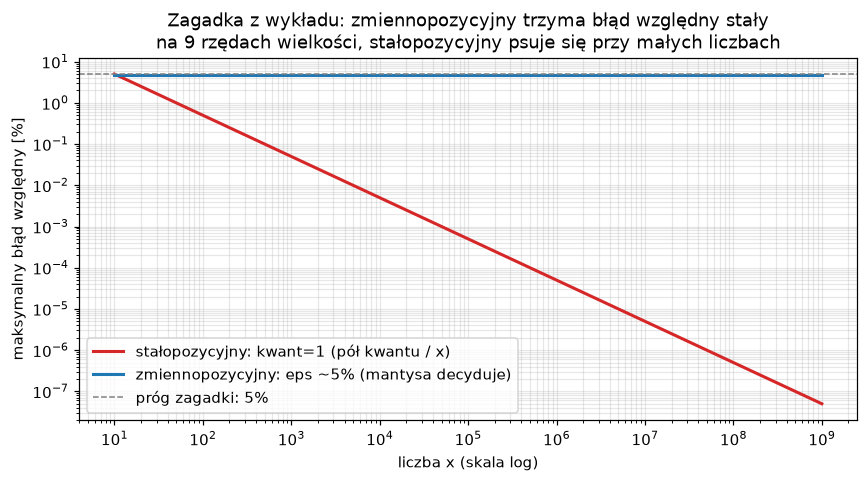

In [6]:
# Demo 3: stałopozycyjny vs zmiennopozycyjny zapis — liczby prosto ze slajdów 36-37
# oraz granice worst-case (pół kwantu) dla każdej dekady przedziału [10, 1e9].
import numpy as np
import matplotlib.pyplot as plt
from math import floor, log10

przyklady = [10.5, 10.49, 11.5, 66666.66666, 1024772.7, 720342529.5]
print(f"{'liczba':>14} | {'stałopoz. (9 cyfr)':>18} | {'błąd':>8} | {'zmiennopoz. (3 cyfry)':>22} | {'błąd':>8}")
for x in przyklady:
    s = round(x)                                   # 9 cyfr na pozycje: kwant = 1
    e = floor(log10(abs(x)))
    z = round(x/10**e, 1) * 10**e                  # 3 cyfry zapisu: mantysa d.d + cecha
    print(f"{x:>14} | {s:>18} | {100*abs(s-x)/x:7.3f}% | {z:>22} | {100*abs(z-x)/x:7.3f}%")

print()
print("Wzór na błąd w zapisie zmiennopozycyjnym: eps = p^(1-n); tu p=10, n=2 -> 5%")
print("(mantysa 2 cyfry znaczące: kwant na ostatniej cyfrze mantysy to 10% mantysy,")
print(" czyli najgorszy przypadek przy zaokrąglaniu do najbliższej: 5%.)")

# wykres worst-case: polowa kwantu dzielona przez wartosc (stalopoz: kwant staly 1)
x = np.logspace(1, 9, 300)
d_stalo = 0.5/x                      # kwant=1, zaokrąglanie do najblizszej: max 0.5
d_zmienn = np.full_like(x, 0.05/1.05) # mantysa 2 cyfry: 0.05 kwantu mantysy / mantysa min 1.0
plt.figure(figsize=(8, 4.5))
plt.loglog(x, d_stalo*100, 'tab:red', lw=2, label='stałopozycyjny: kwant=1 (pół kwantu / x)')
plt.loglog(x, d_zmienn*100, 'tab:blue', lw=2, label='zmiennopozycyjny: eps ~5% (mantysa decyduje)')
plt.axhline(5, color='gray', ls='--', lw=1, label='próg zagadki: 5%')
plt.xlabel('liczba x (skala log)'); plt.ylabel('maksymalny błąd względny [%]')
plt.title('Zagadka z wykładu: zmiennopozycyjny trzyma błąd względny stały\nna 9 rzędach wielkości, stałopozycyjny psuje się przy małych liczbach')
plt.legend(); plt.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()
print()
print("Odpowiedź slajdu 36: 9 cyfr stałopoz. wystarcza — bo przedział zaczyna się od 10,")
print("a kwant=1 przy x=10 daje błąd <5% (1/10/2=5%); dla liczb mniejszych by nie wystarczyło.")

## Błąd zaokrągleń: gdy dane są dokładne, a wynik i tak jest zepsuty

Slajdy 51–53: 1 i 3 są zapisywane dokładnie w double, ale 1/3 już nie — maszyna musi
zaokrąglić wynik **każdej operacji**. Model z wykładu: wynik operacji elementarnej
obciążony jest błędem zaokrąglenia $\eta$ rzędu eps. To dlatego „rachunek epsilonów"
z ILUSTR 2 działa: każda operacja dokłada swój kwant błędu.

Zobaczmy klasyczne objawy na float32:

In [8]:
# Demo 4: objawy błędu zaokrągleń — trzy klasyki.
import numpy as np

print("1) 0.1 + 0.2 == 0.3 :", 0.1+0.2 == 0.3)
print("   bo 0.1+0.2 ==", repr(0.1+0.2), " (0.3 nie ma w double)")

print()
print("2) 0.1 * 3 == 0.3 :")
print("   float64:", 0.1*3 == 0.3, " — bo 0.1 nie ma dokladnej reprezentacji,")
print("   a kazde mnozenie zaokragla wynik (repr:", repr(0.1*3), ")")

print()
print("3) odejmowanie bliskich liczb (catastrophic cancellation):")
# para bliskich liczb: roznica wynosi 2e-6, ale w float32 liczby sa zapisane
# z bledem reprezentacji rzędu eps32*1.2 ~ 1.4e-7 KAZDA
a = np.float32(1.2345671); b = np.float32(1.2345651)
roznica_dokl = 1.2345671 - 1.2345651          # float64: pelne cyfry
roznica_f32  = float(a - b)
print(f"   roznica dokladna: {roznica_dokl:.4e}")
print(f"   roznica w float32: {roznica_f32:.4e}  -> blad wzgledny wyniku: {100*abs(roznica_f32-roznica_dokl)/roznica_dokl:.1f}%")
print("   oba skladniki zapisane byly poprawnie do ~7 cyfr, ale ICH ROZNICA")
print("   ma tylko ~1 cyfre znaczaca: odejmowanie UNICESTWIA dokladnosc")

print()
print("4) sumowanie kwantow: 0.1 dodane 10 razy:")
s = np.float32(0)
for _ in range(10):
    s = np.float32(s + np.float32(0.1))
print(f"   float32: {s}   (float64: {0.1*10})")
print("   kazde dodanie doklada blad zaokraglenia — po 10 krokach widoczny golym okiem")

1) 0.1 + 0.2 == 0.3 : False
   bo 0.1+0.2 == 0.30000000000000004  (0.3 nie ma w double)

2) 0.1 * 3 == 0.3 :
   float64: False  — bo 0.1 nie ma dokladnej reprezentacji,
   a kazde mnozenie zaokragla wynik (repr: 0.30000000000000004 )

3) odejmowanie bliskich liczb (catastrophic cancellation):
   roznica dokladna: 2.0000e-06
   roznica w float32: 1.9073e-06  -> blad wzgledny wyniku: 4.6%
   oba skladniki zapisane byly poprawnie do ~7 cyfr, ale ICH ROZNICA
   ma tylko ~1 cyfre znaczaca: odejmowanie UNICESTWIA dokladnosc

4) sumowanie kwantow: 0.1 dodane 10 razy:
   float32: 1.0000001192092896   (float64: 1.0)
   kazde dodanie doklada blad zaokraglenia — po 10 krokach widoczny golym okiem


## Złożoność obliczeniowa: drugi filar kosztu

Konspekt: koszt rozwiązania problemu ma dwa oblicza — dokładność (błędy, ILUSTR 1–2) i
złożoność (ile operacji). Klasy złożoności $O(g(n))$ porównują algorytmy przez
**asymptotyczne tempo wzrostu** nakładów z rozmiarem problemu $n$.

Tabela poniżej odpowiada na pytanie „ile sekund przy 10⁹ operacji/s" — dla klas
z konspektu: logarytmiczna, liniowa, liniowo-logarytmiczna, kwadratowa, sześcienna,
wykładnicza, silniowa.

                                      n=1,000     n=1,000,000 n=1,000,000,000
logarytmiczna O(log n)                 10 ns           20 ns           30 ns
liniowa O(n)                            1 us            1 ms             1 s
liniowo-log O(n log n)                 10 us           20 ms            30 s
kwadratowa O(n^2)                       1 ms          17 min        31.7 lat
sześcienna O(n^3)                        1 s        31.7 lat         10^18 s
wykładnicza O(2^n)                  10^292 s        10^298 s        10^298 s
silniowa O(n!)                     10^2558 s    10^5565699 s

Przy 10^9 operacji/s:
  n=1e6: n^2 to 17 minut, n^3 to 32 lata — a to JESZCZE 'praktyczne' klasy.
  2^n i n! to wieki/wszechświat — dlatego konspekt mówi: nie nadają się do implementacji.


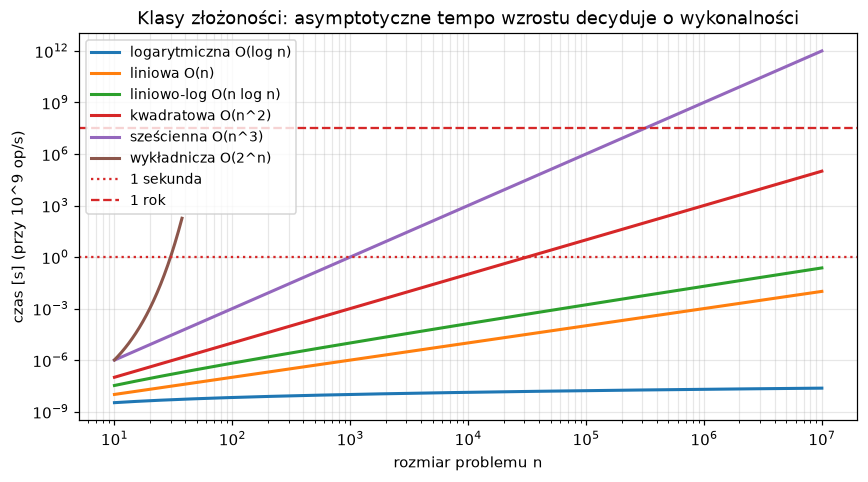

In [10]:
# Demo 5: klasy złożoności — tabela inżynierska (ile CZASU przy 1 GHz operacji/s).
import math
import numpy as np

R = 1e9    # 1e9 operacji na sekunde (komputer inzynierski)

def formatuj_czas(t):
    """Sekundy -> czytelny lancuch (ns/us/ms/s/minuty/lata/10^x s)."""
    if t < 1e-6: return f"{t*1e9:.0f} ns"
    if t < 1e-3: return f"{t*1e6:.0f} us"
    if t < 1:    return f"{t*1e3:.0f} ms"
    if t < 120:  return f"{t:.0f} s"
    if t < 7200: return f"{t/60:.0f} min"
    if t < 3.15e7: return f"{t/3600:.1f} h"
    if t < 3.15e9: return f"{t/3.15e7:.1f} lat"
    return f"10^{int(math.log10(t))} s"

klasy = [
    ("logarytmiczna O(log n)",  lambda n: np.log2(n)),
    ("liniowa O(n)",            lambda n: n),
    ("liniowo-log O(n log n)",  lambda n: n*np.log2(n)),
    ("kwadratowa O(n^2)",       lambda n: n**2),
    ("sześcienna O(n^3)",       lambda n: n**3),
    ("wykładnicza O(2^n)",      lambda n: 2.0**np.minimum(n, 1023)),
]
rozmiary = [1e3, 1e6, 1e9]

print(f"{'':28s}", "".join(f"{'n=' + format(int(r), ','):>16s}" for r in rozmiary))
for nazwa, f in klasy:
    wiersz = f"{nazwa:28s}"
    for r in rozmiary:
        wiersz += f"{formatuj_czas(f(r)/R):>16s}"
    print(wiersz)

# silnia osobno (Stirling) — bo 2^n i n! nie mieszczą się w floatach dla n=1e6
print(f"{'silniowa O(n!)':28s}", end="")
for r in rozmiary:
    if r <= 1e6:
        log10_t = (r*math.log10(r/math.e) + 0.5*math.log10(2*math.pi*r)) - 9
        print(f"{'10^' + str(int(log10_t)) + ' s':>16s}", end="")
print()

print()
print("Przy 10^9 operacji/s:")
print("  n=1e6: n^2 to 17 minut, n^3 to 32 lata — a to JESZCZE 'praktyczne' klasy.")
print("  2^n i n! to wieki/wszechświat — dlatego konspekt mówi: nie nadają się do implementacji.")

# Wykres: wzrost czasu vs rozmiar (skala log-log)
import matplotlib.pyplot as plt
n = np.logspace(1, 7, 200)
plt.figure(figsize=(8, 4.5))
for nazwa, f in klasy[:5]:
    plt.loglog(n, f(n)/R, lw=2, label=nazwa)
n_exp = n[n <= 40]                          # 2^n rosnie za szybko na wieksze n
plt.loglog(n_exp, 2.0**n_exp/R, lw=2, label='wykładnicza O(2^n)')
plt.axhline(1, color='tab:red', ls=':', lw=1.5, label='1 sekunda')
plt.axhline(3.15e7, color='tab:red', ls='--', lw=1.5, label='1 rok')
plt.xlabel('rozmiar problemu n'); plt.ylabel('czas [s] (przy 10^9 op/s)')
plt.title('Klasy złożoności: asymptotyczne tempo wzrostu decyduje o wykonalności')
plt.legend(fontsize=9); plt.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

## Najważniejsze wnioski

- eps maszynowy to górne oszacowanie błędu reprezentacji: float32 ~1.19e-7 (24 bity),
  float64 ~2.22e-16 (53 bity); wzór konspektu $\mathrm{eps} = p^{1-n}$.
- Liczby zmiennopozycyjne są rozmieszczone **geometrycznie**: w każdej oktawie tyle samo
  liczb, odstępy rosną z wielkością — dlatego błąd względny jest (prawie) stały,
  a „dziura podzerowa" zaczyna się od ~1e-38.
- Zapis zmiennopozycyjny wygrywa zagadkę z wykładu: błąd względny ~stały na 9 rzędach
  wielkości (mantysa decyduje), stałopozycyjny psuje się przy małych wartościach.
- Błąd zaokrągleń $\eta$ dokłada się do **każdej operacji** (0.1+0.2≠0.3; sumy kwantów;
  katastrofalne odejmowanie bliskich liczb) — to fizyczna realizacja modelu
  „rachunku epsilonów" z ILUSTR 2.
- Złożoność: asymptotyczne tempo wzrostu decyduje o wykonalności — $n^2$ vs $n^3$
  to 17 minut vs 32 lata przy $n=10^6$; klasy wykładnicza/silniowa są poza praktyką.
- W większości problemów złożoność można wymienić na dokładność (więcej obliczeń →
  dokładniejszy wynik) — ale nigdy nie łamiąc bariery eps maszyny.

In [12]:
# ĆWICZENIE (szkielet — uzupełnij miejsca oznaczone TODO):
#
# 1) Policz eps dla "maszyny dziesiętnej" z konspektu: p=10, n=2 (2 cyfry mantysy).
#    Sprawdź wzór eps = p^(1-n): 10^(1-2) = 0.1. Zaprojektuj eksperyment: losuj liczby
#    z [1,10), zaokrąglaj mantysę do 2 cyfr i zmierz maksymalny błąd względny — czy 5%?
import random
# TODO: 1000 losowych, zaokrąglenie do 2 cyfr znaczacych, max błąd względny

# 2) Ile wynosi spacing float64 wokół liczby 1e15? A co się dzieje, gdy do 1e15
#    dodasz 1.0? Ile razy trzeba dodać 1.0, żeby wynik się zmienił?
print(np.spacing(1e15))
# TODO: dodawanie 1.0 do 1e15 w pętli — po ilu krokach wynik rośnie?

# 3) Oszacuj, dla jakiego n czas O(n^2) przy 1e9 op/s przekracza rok (3.15e7 s).
#    Policz ręcznie sqrt(3.15e16) i zweryfikuj: n > 1.8e8.
print(math.sqrt(3.15e7*1e9))


0.125
177482393.49298847


## Wykorzystywane funkcje

- `np.nextafter(a, b)` — kolejna liczba reprezentowalna; droga do eps i spacing,
- `np.spacing(u)` — odstęp między sąsiednimi liczbami zmiennopozycyjnymi wokół u,
- `np.logspace` — siatka logarytmiczna do wykresów z rozkładem liczb,
- `math.log2`, `math.log10` — logarytmy do tabel złożoności (Stirling dla n!).

## Ćwiczenie — wskazówki

1) do zaokrąglenia mantysy przyda się `round(x, -int(floor(log10(x))) + 1)`;
   zmierzony max błąd powinien wyjść ~5% (pół kwantu na obu stronach: 1/(2*10)=5%).
2) `np.spacing(1e15) = 0.125`; dodanie 1.0 jest poniżej połowy kwantu — ginie;
   żeby ruszyć wynik, trzeba dodać co najmniej ~0.0625 (pół kwantu) naraz.
3) rozwiąż równanie $n^2/10^9 = 3.15\cdot10^7 \Rightarrow n = \sqrt{3.15\cdot10^{16}}$.